In [1]:
# Cellule 1 — d'abord une stack compilée cohérente (wheels PyPI, même ABI numpy 1.x)
!pip install -q --force-reinstall --no-cache-dir numpy==1.26.4 pandas==2.2.2 tables

# puis les packages purement Python, build isolation NORMALE (pas de --no-build-isolation)
!pip install -q networkx
!pip install -q git+https://github.com/nilmtk/nilm_metadata.git
!pip install -q git+https://github.com/nilmtk/nilmtk.git

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 91.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.4/109.4 kB 182.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 121.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 231.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 151.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 250.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.7/6.7 MB 227.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 443.6/443.6 kB 265.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 229.9/229.9 kB 216.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.1/510.1 kB 294.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 292.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.2/100.2 kB 230.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━

In [2]:
from nilmtk import DataSet
from collections import Counter
print("NILMTK installed and imported successfully")
print("collections imported successfully")

NILMTK installed and imported successfully
collections imported successfully


In [3]:
# ===== CELLULE 0 : imports =====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from collections import Counter
from nilmtk import DataSet

SAMPLE_PERIOD = 6  # secondes

In [4]:
# ===== CELLULE 1 : chargement + maison 1 =====
ukdale = DataSet('/kaggle/input/datasets/abdelmdz/uk-dale/ukdale.h5')
elec = ukdale.buildings[1].elec

In [5]:
# ===== CELLULE 2 : inventaire des types d'appareils =====
# On passe par app.identifier au lieu de découper label() à la main :
# identifier est un namedtuple ApplianceID(type, instance), plus robuste.
appliance_names = [app.identifier.type for app in elec.appliances]
counts = Counter(appliance_names)

print(counts)
print("Total appareils      :", len(appliance_names))
print("Types distincts      :", len(counts))

Counter({'light': 16, 'laptop computer': 3, 'radio': 3, 'food processor': 2, 'broadband router': 2, 'washer dryer': 2, 'fan': 2, 'mobile phone charger': 2, 'baby monitor': 2, 'audio system': 2, 'soldering iron': 1, 'kitchen aid': 1, 'computer monitor': 1, 'fridge freezer': 1, 'wireless phone charger': 1, 'HTPC': 1, 'toasted sandwich maker': 1, 'hair dryer': 1, 'clothes iron': 1, 'desktop computer': 1, 'solar thermal pumping station': 1, 'USB hub': 1, 'breadmaker': 1, 'ethernet switch': 1, 'hair straighteners': 1, 'dish washer': 1, 'audio amplifier': 1, 'security alarm': 1, 'active subwoofer': 1, 'bouncy castle pump': 1, 'toaster': 1, 'oven': 1, 'microwave': 1, 'computer': 1, 'drill': 1, 'tablet computer charger': 1, 'boiler': 1, 'vacuum cleaner': 1, 'charger': 1, 'water pump': 1, 'external hard disk': 1, 'kettle': 1, 'printer': 1, 'coffee maker': 1, 'immersion heater': 1, 'television': 1})
Total appareils      : 72
Types distincts      : 46


In [6]:
# ===== CELLULE 3 : mains =====
mains = elec.mains()
df_mains = next(mains.load())
print(df_mains.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 128238700 entries, 2013-03-17 19:12:43.100000+00:00 to 2017-04-26 18:35:58.500000+01:00
Data columns (total 3 columns):
 #   Column             Dtype  
---  ------             -----  
 0   (power, active)    float32
 1   (voltage, )        float32
 2   (power, apparent)  float32
dtypes: float32(3)
memory usage: 2.4 GB
None


In [7]:
# ===== CELLULE 4 : inventaire des submeters (nb d'appareils + dates_active) =====
for i, meter in enumerate(elec.submeters().meters):
    apps = meter.appliances
    print('#'*30, f'meter index {i} (instance {meter.instance()})', '#'*30)
    print(f"  nb appareils sur ce meter : {len(apps)}")
    for app in apps:
        print("   ->", app.identifier,
              "| dates_active:", app.metadata.get('dates_active', 'n/a'))

############################## meter index 0 (instance 2) ##############################
  nb appareils sur ce meter : 1
   -> ApplianceID(type='boiler', instance=1) | dates_active: n/a
############################## meter index 1 (instance 3) ##############################
  nb appareils sur ce meter : 1
   -> ApplianceID(type='solar thermal pumping station', instance=1) | dates_active: n/a
############################## meter index 2 (instance 4) ##############################
  nb appareils sur ce meter : 2
   -> ApplianceID(type='laptop computer', instance=1) | dates_active: n/a
   -> ApplianceID(type='laptop computer', instance=3) | dates_active: [{'start': '2014-07-14T00:00:00+01:00', 'end': '2014-10-24T23:59:59+01:00'}]
############################## meter index 3 (instance 5) ##############################
  nb appareils sur ce meter : 2
   -> ApplianceID(type='washer dryer', instance=1) | dates_active: [{'end': '2015-09-08T00:00:00+01:00'}]
   -> ApplianceID(type='washer dryer

In [8]:
# ===== CELLULE 5 : fonctions utilitaires =====

def load_meter_power(meter, sample_period=SAMPLE_PERIOD):
    """Charge la série de puissance d'un meter.
    Choisit 'active' si dispo, sinon 'apparent'. Renvoie (series, ac_type)."""
    acs = meter.available_ac_types('power')
    if not acs:
        return None, None
    ac = 'active' if 'active' in acs else 'apparent'
    chunks = list(meter.load(ac_type=ac, sample_period=sample_period))
    if not chunks:
        return None, ac
    df = pd.concat(chunks)
    col = ('power', ac)
    s = df[col] if col in df.columns else df.iloc[:, 0]
    s = s.astype('float32')          # mémoire : ~23M pts par série
    s.name = f"{meter.instance()}_{ac}"
    return s, ac


def parse_dates_active(app):
    """Renvoie [(start, end), ...] en Timestamps (ou None aux bornes ouvertes),
    ou None si dates_active est absent / vide."""
    da = app.metadata.get('dates_active', None)
    if not da:                       # None ou []
        return None
    windows = []
    for d in da:
        start = pd.Timestamp(d['start']) if d.get('start') else None
        end   = pd.Timestamp(d['end'])   if d.get('end')   else None
        windows.append((start, end))
    return windows or None


def mask_outside_windows(series, windows):
    """Met NaN partout en dehors des fenêtres dates_active.
    Gère l'index tz-aware (Europe/London) d'UK-DALE."""
    if not windows:
        return series.astype('float32')
    idx = series.index
    tz = idx.tz
    keep = np.zeros(len(idx), dtype=bool)
    for start, end in windows:
        lo = idx[0]  if start is None else pd.Timestamp(start)
        hi = idx[-1] if end   is None else pd.Timestamp(end)
        if tz is not None:
            if lo.tzinfo is None:
                lo = lo.tz_localize(tz, ambiguous='NaT', nonexistent='shift_forward')
            if hi.tzinfo is None:
                hi = hi.tz_localize(tz, ambiguous='NaT', nonexistent='shift_forward')
        keep |= (idx >= lo) & (idx <= hi)
    out = series.astype('float32').copy()
    out[~keep] = np.nan
    return out


def any_overlap(win_a, win_b):
    """True si deux jeux de fenêtres se chevauchent.
    None = borne ouverte (-inf pour start, +inf pour end).
    On ne compare que des timestamps réels entre eux -> pas de souci tz."""
    def overlaps(s1, e1, s2, e2):
        # [s1,e1] et [s2,e2] disjoints ssi  e1 <= s2  ou  e2 <= s1
        # (<= : deux fenetres qui se TOUCHENT, cas remplacement A->B, ne comptent pas)
        if e1 is not None and s2 is not None and e1 <= s2:
            return False
        if e2 is not None and s1 is not None and e2 <= s1:
            return False
        return True
    for (s1, e1) in win_a:
        for (s2, e2) in win_b:
            if overlaps(s1, e1, s2, e2):
                return True
    return False

In [9]:
# ===== CELLULE 6 : extraction de tous les submeters =====
# Logique :
#  - meter à 1 appareil  -> série brute attribuée à l'appareil
#  - meter à N appareils -> si TOUS ont dates_active : on masque (NaN) hors fenêtre
#                          -> sinon : non séparable -> regroupé dans "autres"
# Séparation active / apparente respectée (homogénéité à l'entraînement).
# Construit aussi : seuils_meta, seuils_origine, obj_par_key (pour la saisie 6.5).

SEUIL_DEFAUT = 10.0   # W (repli quand aucune info dans le metadata)

def get_on_threshold_from_app(app, defaut=SEUIL_DEFAUT):
    """Renvoie (seuil, origine) par ordre de priorité :
       1) on_power_threshold (explicite)
       2) 50% de nominal_consumption.on_power
       3) 50% de distributions.on_power.model.mu
       4) défaut."""
    m = app.metadata
    thr = m.get('on_power_threshold')
    if thr is not None:
        return float(thr), 'on_power_threshold'
    nom = m.get('nominal_consumption', {})
    if isinstance(nom, dict) and nom.get('on_power') is not None:
        return 0.5 * float(nom['on_power']), 'nominal/2'
    on_dist = m.get('distributions', {}).get('on_power')
    if on_dist:
        mu = on_dist[0].get('model', {}).get('mu')
        if mu is not None:
            return 0.5 * float(mu), 'mu/2'
    return defaut, 'defaut'

def get_on_threshold_meter(meter, defaut=SEUIL_DEFAUT):
    """Meter multi-appareils non séparable : seuil le plus sensible (min)."""
    pairs = [get_on_threshold_from_app(a, defaut) for a in meter.appliances]
    if not pairs:
        return defaut, 'defaut'
    return min(pairs, key=lambda p: p[0])   # (val, origine)


D_active   = {}   # appareils mesurés en puissance ACTIVE
D_apparent = {}   # appareils mesurés en puissance APPARENTE
autres     = {}   # meters non séparables
ac_used    = {}
seuils_meta    = {}   # key -> seuil ON (W)
seuils_origine = {}   # key -> origine du seuil
obj_par_key    = {}   # key -> ('app', app) ou ('meter', meter)

for meter in elec.submeters().meters:
    apps = meter.appliances
    s, ac = load_meter_power(meter)
    if s is None:
        print(f"meter {meter.instance()} : pas de 'power' -> skip")
        continue
    target = D_active if ac == 'active' else D_apparent

    # --- 1 seul appareil ---
    if len(apps) == 1:
        key = apps[0].identifier
        target[key] = s
        ac_used[key] = ac
        seuils_meta[key], seuils_origine[key] = get_on_threshold_from_app(apps[0])
        obj_par_key[key] = ('app', apps[0])
        continue

    # --- plusieurs appareils ---
    win = {app.identifier: parse_dates_active(app) for app in apps}
    separable = all(w is not None for w in win.values())

    if separable:
        # diagnostic chevauchement : fenêtres qui se recouvrent
        # -> même puissance attribuée à 2 appareils -> séparation illusoire
        ids = list(win.keys())
        for a in range(len(ids)):
            for b in range(a + 1, len(ids)):
                if any_overlap(win[ids[a]], win[ids[b]]):
                    print(f"  ATTENTION chevauchement : {ids[a]} & {ids[b]} "
                          f"(meter {meter.instance()}) -> séparation non fiable")
        for app in apps:
            key = app.identifier
            target[key] = mask_outside_windows(s, win[key])
            ac_used[key] = ac
            seuils_meta[key], seuils_origine[key] = get_on_threshold_from_app(app)
            obj_par_key[key] = ('app', app)
    else:
        label = f"autres_meter_{meter.instance()}"
        autres[label] = s
        ac_used[label] = ac
        seuils_meta[label], seuils_origine[label] = get_on_threshold_meter(meter)
        obj_par_key[label] = ('meter', meter)
        print(f"meter {meter.instance()} : {len(apps)} appareils sans dates_active "
              f"complets -> regroupés dans '{label}'")

print("\nActive  :", len(D_active))
print("Apparent:", len(D_apparent))
print("Autres  :", len(autres))
print(Counter(ac_used.values()))

meter 4 : 2 appareils sans dates_active complets -> regroupés dans 'autres_meter_4'
meter 10 : 3 appareils sans dates_active complets -> regroupés dans 'autres_meter_10'
meter 11 : 3 appareils sans dates_active complets -> regroupés dans 'autres_meter_11'
meter 21 : 2 appareils sans dates_active complets -> regroupés dans 'autres_meter_21'
meter 32 : 2 appareils sans dates_active complets -> regroupés dans 'autres_meter_32'
meter 38 : 3 appareils sans dates_active complets -> regroupés dans 'autres_meter_38'
meter 43 : 2 appareils sans dates_active complets -> regroupés dans 'autres_meter_43'

Active  : 44
Apparent: 5
Autres  : 7
Counter({'active': 51, 'apparent': 5})


In [22]:
# ===== CELLULE 6.6 : seuils figés en dur (source de vérité unique) =====
seuils_manuels = {
    ('HTPC', 1): 20,
    ('active subwoofer', 1): 20,
    ('audio amplifier', 1): 10,
    ('audio system', 1): 10,
    'autres_meter_10': 2000,
    'autres_meter_11': 1000,
    'autres_meter_21': 20,
    'autres_meter_32': 20,
    'autres_meter_38': 1,
    'autres_meter_4': 10,
    'autres_meter_43': 20,
    ('baby monitor', 1): 10,
    ('boiler', 1): 35,
    ('bouncy castle pump', 1): 20,
    ('breadmaker', 1): 10,
    ('broadband router', 1): 10,
    ('broadband router', 2): 10,
    ('charger', 1): 10,
    ('clothes iron', 1): 50,
    ('coffee maker', 1): 50,
    ('computer monitor', 1): 10,
    ('desktop computer', 1): 20,
    ('dish washer', 1): 10,
    ('fan', 1): 20,
    ('fridge freezer', 1): 50,
    ('hair dryer', 1): 50,
    ('hair straighteners', 1): 50,
    ('light', 1): 50,
    ('light', 10): 20,
    ('light', 11): 20,
    ('light', 12): 20,
    ('light', 13): 20,
    ('light', 14): 20,
    ('light', 15): 20,
    ('light', 16): 20,
    ('light', 2): 250,
    ('light', 3): 20,
    ('light', 4): 20,
    ('light', 5): 20,
    ('light', 6): 20,
    ('light', 7): 20,
    ('light', 8): 20,
    ('light', 9): 20,
    ('microwave', 1): 200,
    ('mobile phone charger', 1): 20,
    ('oven', 1): 10,
    ('printer', 1): 30,
    ('radio', 1): 10,
    ('radio', 2): 2,
    ('solar thermal pumping station', 1): 21.5,
    ('soldering iron', 1): 50,
    ('tablet computer charger', 1): 20,
    ('television', 1): 10,
    ('vacuum cleaner', 1): 50,
    ('washer dryer', 1): 20,
    ('washer dryer', 2): 20,
}
# application : patche seuils_meta sans retoucher les DataFrames
n = 0
for key in list(seuils_meta.keys()):
    mk = key if isinstance(key, str) else (key.type, key.instance)
    if mk in seuils_manuels:
        seuils_meta[key]    = float(seuils_manuels[mk])
        seuils_origine[key] = 'manuel'
        n += 1
print(f"{n} seuils appliqués depuis seuils_manuels.")

def key_to_name(key):
    return key if isinstance(key, str) else f"{key.type} {key.instance}"
print("\nSeuils finaux (W) :")
for key in sorted(seuils_meta, key=key_to_name):
    print(f"  {seuils_meta[key]:8.1f} W  {key_to_name(key)}")

56 seuils appliqués depuis seuils_manuels.

Seuils finaux (W) :
      20.0 W  HTPC 1
      20.0 W  active subwoofer 1
      10.0 W  audio amplifier 1
      10.0 W  audio system 1
    2000.0 W  autres_meter_10
    1000.0 W  autres_meter_11
      20.0 W  autres_meter_21
      20.0 W  autres_meter_32
       1.0 W  autres_meter_38
      10.0 W  autres_meter_4
      20.0 W  autres_meter_43
      10.0 W  baby monitor 1
      35.0 W  boiler 1
      20.0 W  bouncy castle pump 1
      10.0 W  breadmaker 1
      10.0 W  broadband router 1
      10.0 W  broadband router 2
      10.0 W  charger 1
      50.0 W  clothes iron 1
      50.0 W  coffee maker 1
      10.0 W  computer monitor 1
      20.0 W  desktop computer 1
      10.0 W  dish washer 1
      20.0 W  fan 1
      50.0 W  fridge freezer 1
      50.0 W  hair dryer 1
      50.0 W  hair straighteners 1
      50.0 W  light 1
      20.0 W  light 10
      20.0 W  light 11
      20.0 W  light 12
      20.0 W  light 13
      20.0 W  light 14
      

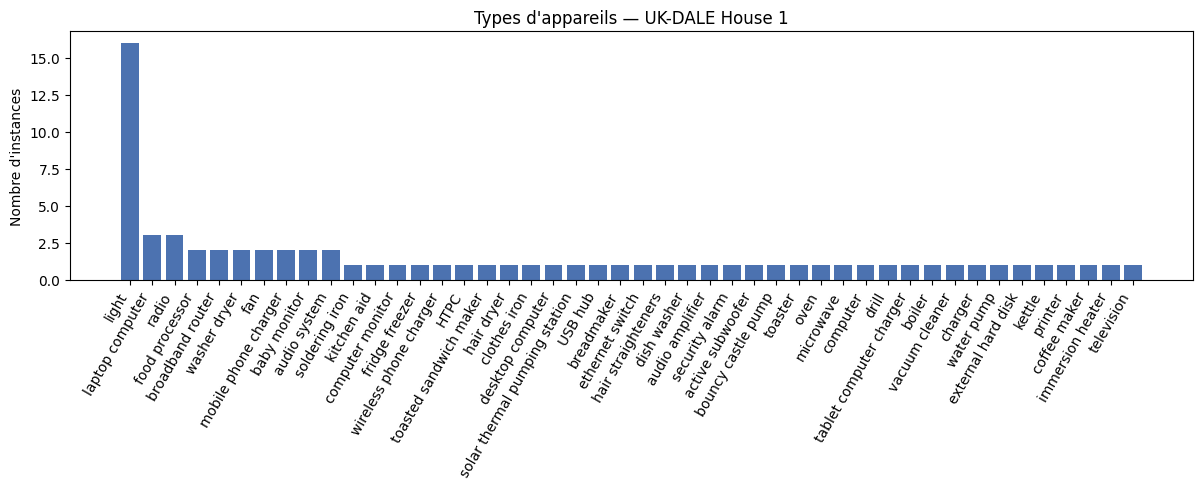

In [23]:
# ===== CELLULE 7 : plot 1 — fréquence des types d'appareils =====
items = counts.most_common()
labels = [k for k, _ in items]
vals   = [v for _, v in items]

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(labels, vals, color='#4C72B0')
ax.set_ylabel("Nombre d'instances")
ax.set_title("Types d'appareils — UK-DALE House 1")
plt.xticks(rotation=60, ha='right')
plt.tight_layout(); plt.show()

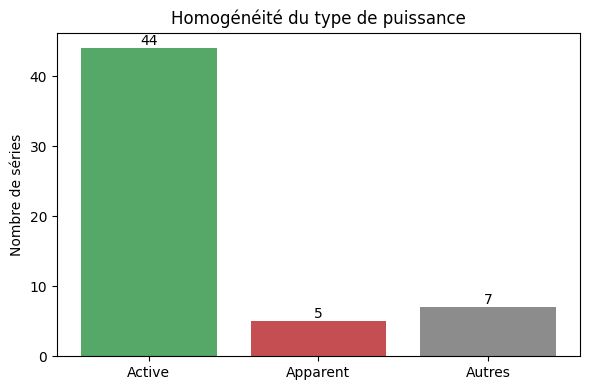

In [24]:
# ===== CELLULE 8 : plot 2 — répartition active / apparente / autres =====
groupes = ['Active', 'Apparent', 'Autres']
tailles = [len(D_active), len(D_apparent), len(autres)]

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(groupes, tailles, color=['#55A868', '#C44E52', '#8C8C8C'])
for i, v in enumerate(tailles):
    ax.text(i, v, str(v), ha='center', va='bottom')
ax.set_ylabel("Nombre de séries")
ax.set_title("Homogénéité du type de puissance")
plt.tight_layout(); plt.show()

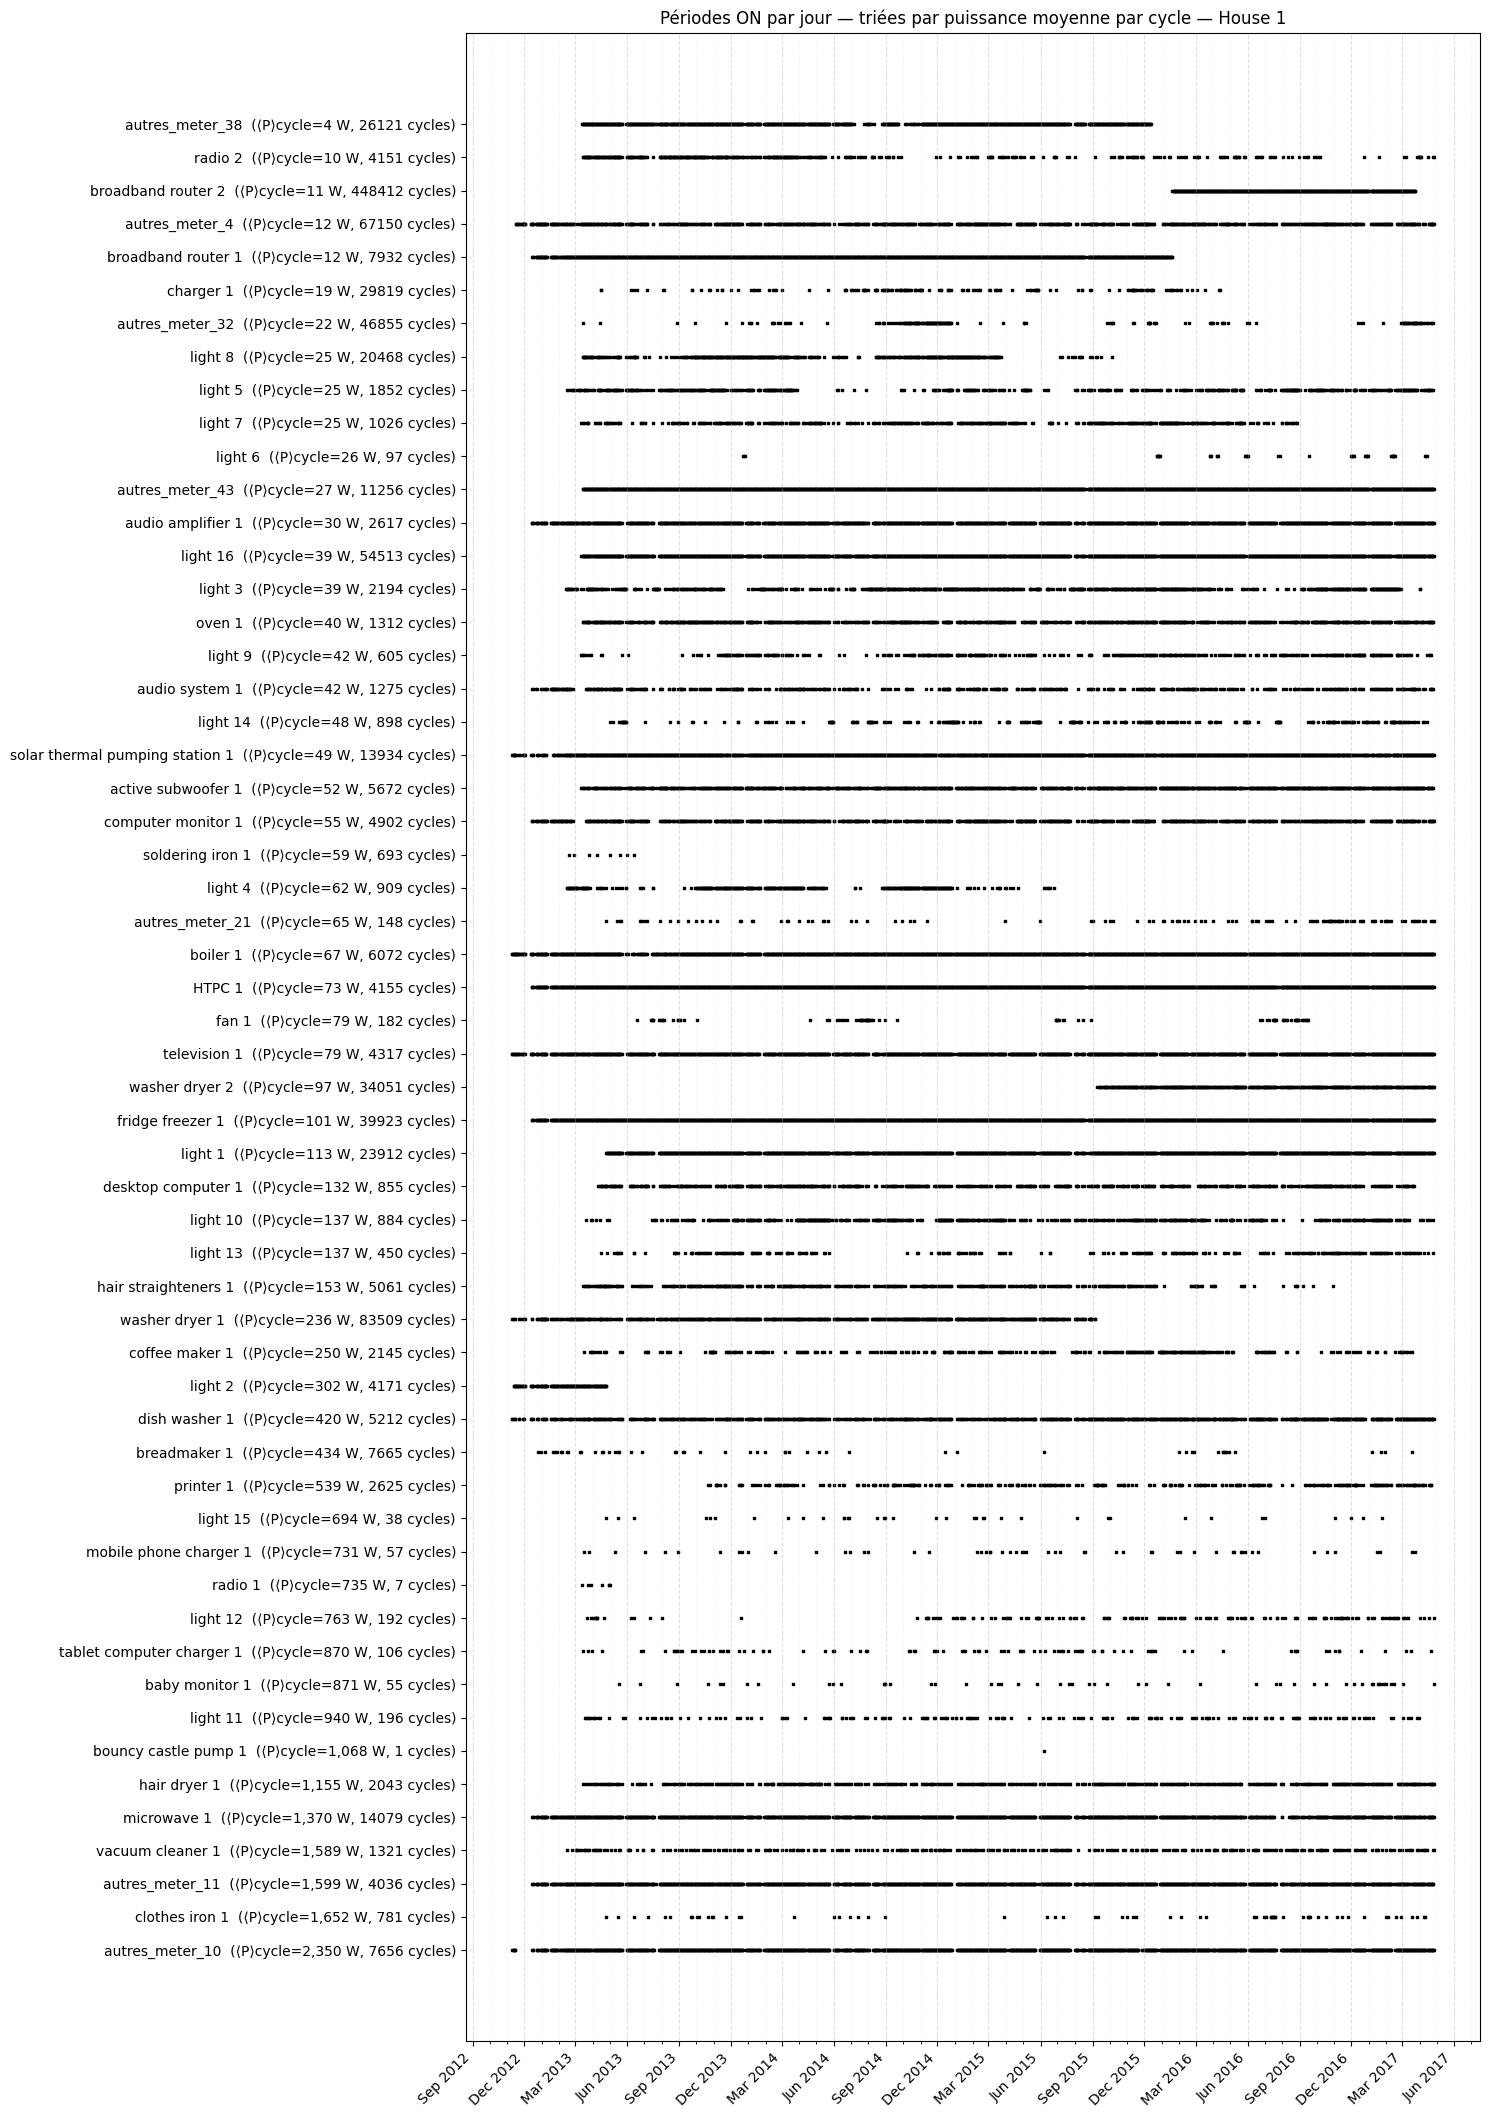

Classement par puissance moyenne par cycle (W) :
    2,349.8 W/cycle   (  7656 cycles, seuil 2000 W)   autres_meter_10
    1,652.3 W/cycle   (   781 cycles, seuil 50 W)   clothes iron 1
    1,599.2 W/cycle   (  4036 cycles, seuil 1000 W)   autres_meter_11
    1,588.8 W/cycle   (  1321 cycles, seuil 50 W)   vacuum cleaner 1
    1,370.1 W/cycle   ( 14079 cycles, seuil 200 W)   microwave 1
    1,155.4 W/cycle   (  2043 cycles, seuil 50 W)   hair dryer 1
    1,068.3 W/cycle   (     1 cycles, seuil 20 W)   bouncy castle pump 1
      940.1 W/cycle   (   196 cycles, seuil 20 W)   light 11
      871.5 W/cycle   (    55 cycles, seuil 10 W)   baby monitor 1
      870.0 W/cycle   (   106 cycles, seuil 20 W)   tablet computer charger 1
      762.8 W/cycle   (   192 cycles, seuil 20 W)   light 12
      734.7 W/cycle   (     7 cycles, seuil 10 W)   radio 1
      731.2 W/cycle   (    57 cycles, seuil 20 W)   mobile phone charger 1
      693.9 W/cycle   (    38 cycles, seuil 20 W)   light 15
      538

In [26]:
# ===== CELLULE 9 : timeline ON/jour + tri par PUISSANCE MOYENNE PAR CYCLE =====
import numpy as np
import matplotlib.dates as mdates

def get_seuil(key):
    return seuils_meta.get(key, SEUIL_DEFAUT)

GAP_MAX = pd.Timedelta(seconds=3 * SAMPLE_PERIOD)   # trou -> rupture de cycle

def cycles_stats(s, seuil, sample_period=SAMPLE_PERIOD, gap_max=GAP_MAX):
    """Segmente la série en cycles ON (runs consécutifs > seuil, coupés par
    un retour sous le seuil OU un trou temporel). Renvoie :
      - mean_of_cycle_means : moyenne des puissances moyennes de chaque cycle (W)
      - n_cycles, on_index (index des points ON pour le plot)."""
    s = s.dropna()
    if len(s) == 0:
        return np.nan, 0, s.index[:0]
    on_mask = (s > seuil).values
    if not on_mask.any():
        return np.nan, 0, s.index[:0]

    vals = s.values
    idx  = s.index
    # rupture si : on->off, OU trou temporel > gap_max entre deux points consécutifs
    dt = np.diff(idx.values).astype('timedelta64[ns]').astype('int64')
    gap = np.empty(len(idx), dtype=bool); gap[0] = True
    gap[1:] = dt > np.int64(gap_max.value)

    cycle_means = []
    cur_sum = 0.0; cur_cnt = 0
    for k in range(len(idx)):
        if on_mask[k]:
            # nouveau cycle si point précédent OFF ou trou temporel
            if cur_cnt > 0 and (gap[k] or not on_mask[k-1]):
                cycle_means.append(cur_sum / cur_cnt)
                cur_sum = 0.0; cur_cnt = 0
            cur_sum += vals[k]; cur_cnt += 1
        else:
            if cur_cnt > 0:
                cycle_means.append(cur_sum / cur_cnt)
                cur_sum = 0.0; cur_cnt = 0
    if cur_cnt > 0:
        cycle_means.append(cur_sum / cur_cnt)

    on_index = idx[on_mask]
    if not cycle_means:
        return np.nan, 0, on_index
    return float(np.mean(cycle_means)), len(cycle_means), on_index

# construction
entries = [(f"{k.type} {k.instance}", s, get_seuil(k)) for k, s in {**D_active, **D_apparent}.items()]
entries += [(lbl, s, get_seuil(lbl)) for lbl, s in autres.items()]

ranked = []
for name, s, seuil in entries:
    mcm, ncyc, on_index = cycles_stats(s, seuil)
    if ncyc == 0 or np.isnan(mcm):
        continue
    ranked.append((name, seuil, mcm, ncyc, on_index))

# tri par puissance moyenne PAR CYCLE décroissante -> plus "intense" à i=0 (en bas)
ranked.sort(key=lambda r: r[2], reverse=True)

fig, ax = plt.subplots(figsize=(15, max(4, 0.38 * len(ranked))))
for i, (name, seuil, mcm, ncyc, on_index) in enumerate(ranked):
    jours = pd.Series(1, index=on_index).resample('1D').size()
    jours = jours[jours > 0]
    ax.scatter(jours.index, np.full(len(jours), i), s=4, color='black', marker='s')

ax.set_yticks(range(len(ranked)))
ax.set_yticklabels([f"{name}  (⟨P⟩cycle={mcm:,.0f} W, {ncyc} cycles)"
                    for name, _, mcm, ncyc, _ in ranked])
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_minor_locator(mdates.MonthLocator())
ax.grid(True, axis='x', which='major', linestyle='--', alpha=0.4)
ax.grid(True, axis='x', which='minor', linestyle=':',  alpha=0.2)
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_title("Périodes ON par jour — triées par puissance moyenne par cycle — House 1")
plt.tight_layout(); plt.show()

print("Classement par puissance moyenne par cycle (W) :")
for name, seuil, mcm, ncyc, _ in ranked:
    print(f"  {mcm:9,.1f} W/cycle   ({ncyc:6d} cycles, seuil {seuil:g} W)   {name}")

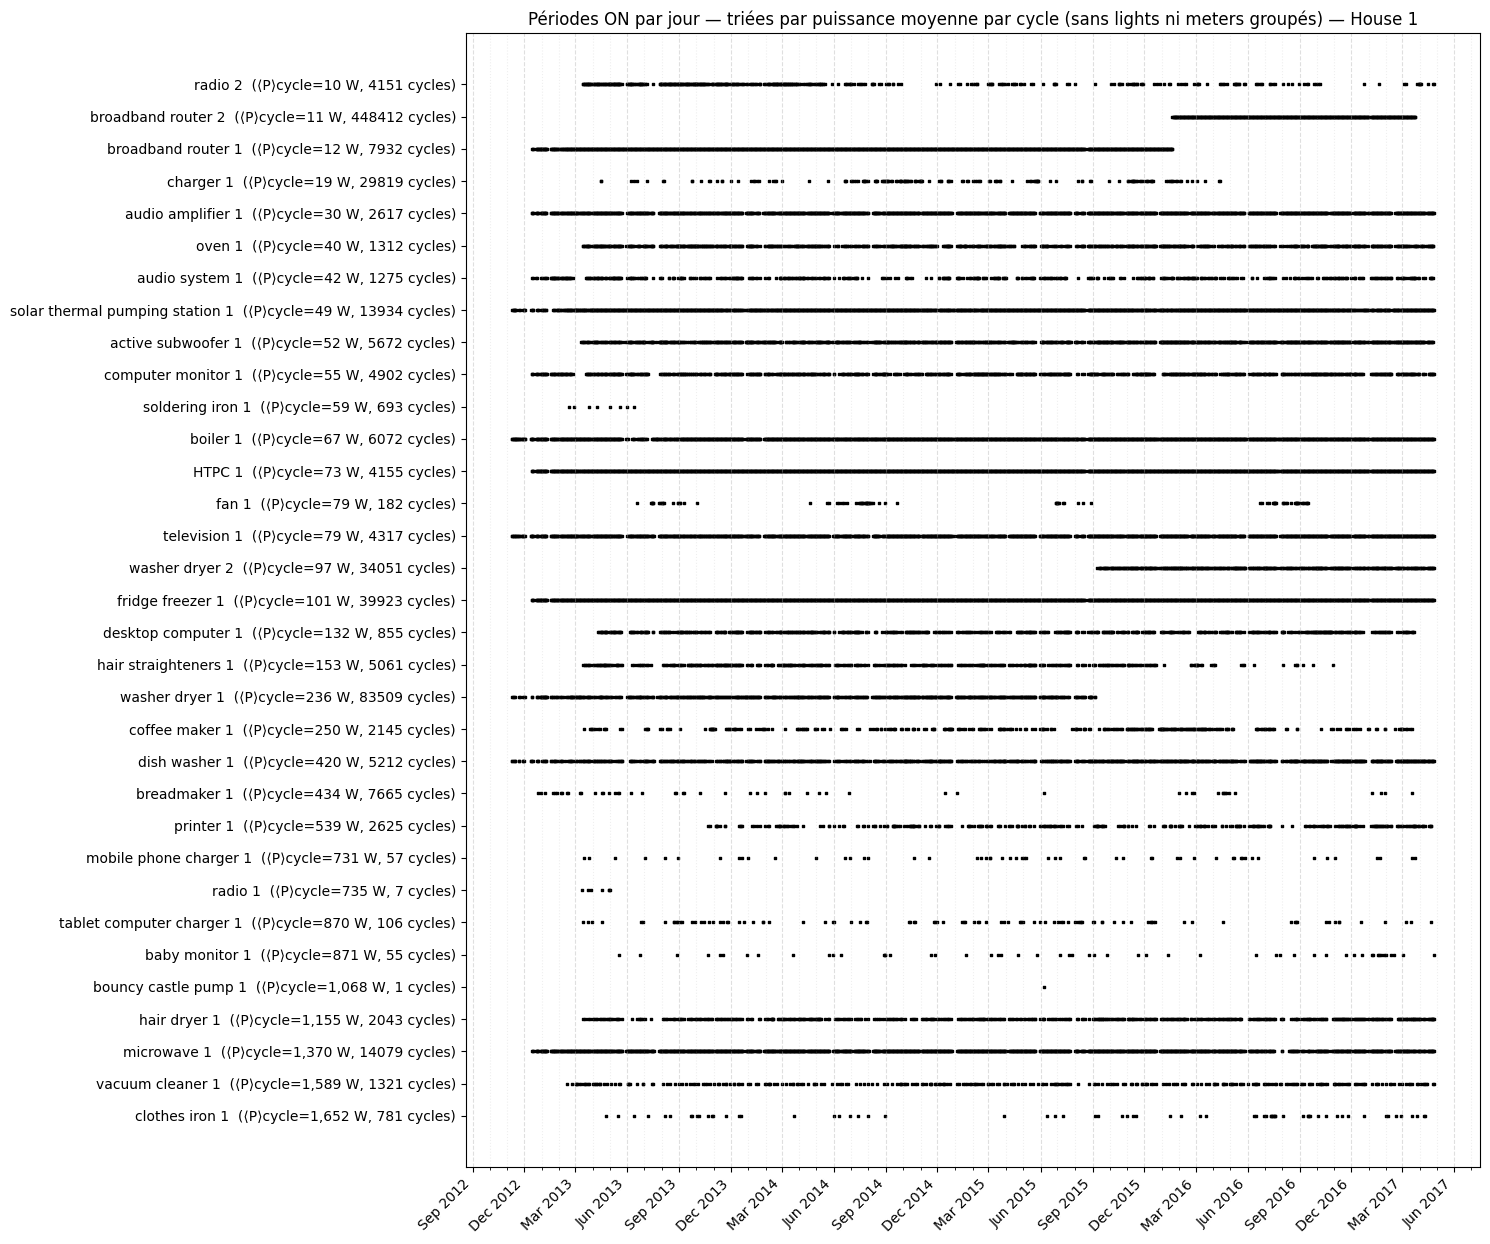

Classement par puissance moyenne par cycle (W) :
    1,652.3 W/cycle   (   781 cycles, seuil 50 W)   clothes iron 1
    1,588.8 W/cycle   (  1321 cycles, seuil 50 W)   vacuum cleaner 1
    1,370.1 W/cycle   ( 14079 cycles, seuil 200 W)   microwave 1
    1,155.4 W/cycle   (  2043 cycles, seuil 50 W)   hair dryer 1
    1,068.3 W/cycle   (     1 cycles, seuil 20 W)   bouncy castle pump 1
      871.5 W/cycle   (    55 cycles, seuil 10 W)   baby monitor 1
      870.0 W/cycle   (   106 cycles, seuil 20 W)   tablet computer charger 1
      734.7 W/cycle   (     7 cycles, seuil 10 W)   radio 1
      731.2 W/cycle   (    57 cycles, seuil 20 W)   mobile phone charger 1
      538.9 W/cycle   (  2625 cycles, seuil 30 W)   printer 1
      434.3 W/cycle   (  7665 cycles, seuil 10 W)   breadmaker 1
      420.1 W/cycle   (  5212 cycles, seuil 10 W)   dish washer 1
      250.4 W/cycle   (  2145 cycles, seuil 50 W)   coffee maker 1
      236.3 W/cycle   ( 83509 cycles, seuil 20 W)   washer dryer 1
     

In [27]:
# ===== CELLULE 10 : timeline ON/jour + tri par PUISSANCE MOYENNE PAR CYCLE =====
# Filtres : on exclut les groupes 'autres_meter_*' et tous les 'light *'.
import numpy as np
import matplotlib.dates as mdates

def get_seuil(key):
    return seuils_meta.get(key, SEUIL_DEFAUT)

GAP_MAX = pd.Timedelta(seconds=3 * SAMPLE_PERIOD)   # trou -> rupture de cycle

def cycles_stats(s, seuil, sample_period=SAMPLE_PERIOD, gap_max=GAP_MAX):
    """Segmente la série en cycles ON (runs consécutifs > seuil, coupés par
    un retour sous le seuil OU un trou temporel). Renvoie :
      - mean_of_cycle_means : moyenne des puissances moyennes de chaque cycle (W)
      - n_cycles, on_index (index des points ON pour le plot)."""
    s = s.dropna()
    if len(s) == 0:
        return np.nan, 0, s.index[:0]
    on_mask = (s > seuil).values
    if not on_mask.any():
        return np.nan, 0, s.index[:0]
    vals = s.values
    idx  = s.index
    # rupture si : on->off, OU trou temporel > gap_max entre deux points consécutifs
    dt = np.diff(idx.values).astype('timedelta64[ns]').astype('int64')
    gap = np.empty(len(idx), dtype=bool); gap[0] = True
    gap[1:] = dt > np.int64(gap_max.value)
    cycle_means = []
    cur_sum = 0.0; cur_cnt = 0
    for k in range(len(idx)):
        if on_mask[k]:
            # nouveau cycle si point précédent OFF ou trou temporel
            if cur_cnt > 0 and (gap[k] or not on_mask[k-1]):
                cycle_means.append(cur_sum / cur_cnt)
                cur_sum = 0.0; cur_cnt = 0
            cur_sum += vals[k]; cur_cnt += 1
        else:
            if cur_cnt > 0:
                cycle_means.append(cur_sum / cur_cnt)
                cur_sum = 0.0; cur_cnt = 0
    if cur_cnt > 0:
        cycle_means.append(cur_sum / cur_cnt)
    on_index = idx[on_mask]
    if not cycle_means:
        return np.nan, 0, on_index
    return float(np.mean(cycle_means)), len(cycle_means), on_index

# --- construction + filtres : exclut 'autres_meter_*' et tous les 'light ' ---
def garder(name):
    return not (name.startswith('autres_meter') or name.startswith('light '))

entries = [(f"{k.type} {k.instance}", s, get_seuil(k))
           for k, s in {**D_active, **D_apparent}.items()
           if garder(f"{k.type} {k.instance}")]
entries += [(lbl, s, get_seuil(lbl))
            for lbl, s in autres.items()
            if garder(lbl)]

ranked = []
for name, s, seuil in entries:
    mcm, ncyc, on_index = cycles_stats(s, seuil)
    if ncyc == 0 or np.isnan(mcm):
        continue
    ranked.append((name, seuil, mcm, ncyc, on_index))

# tri par puissance moyenne PAR CYCLE décroissante -> plus "intense" à i=0 (en bas)
ranked.sort(key=lambda r: r[2], reverse=True)

fig, ax = plt.subplots(figsize=(15, max(4, 0.38 * len(ranked))))
for i, (name, seuil, mcm, ncyc, on_index) in enumerate(ranked):
    jours = pd.Series(1, index=on_index).resample('1D').size()
    jours = jours[jours > 0]
    ax.scatter(jours.index, np.full(len(jours), i), s=4, color='black', marker='s')

ax.set_yticks(range(len(ranked)))
ax.set_yticklabels([f"{name}  (⟨P⟩cycle={mcm:,.0f} W, {ncyc} cycles)"
                    for name, _, mcm, ncyc, _ in ranked])
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_minor_locator(mdates.MonthLocator())
ax.grid(True, axis='x', which='major', linestyle='--', alpha=0.4)
ax.grid(True, axis='x', which='minor', linestyle=':',  alpha=0.2)
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_title("Périodes ON par jour — triées par puissance moyenne par cycle "
             "(sans lights ni meters groupés) — House 1")
plt.tight_layout(); plt.show()

print("Classement par puissance moyenne par cycle (W) :")
for name, seuil, mcm, ncyc, _ in ranked:
    print(f"  {mcm:9,.1f} W/cycle   ({ncyc:6d} cycles, seuil {seuil:g} W)   {name}")

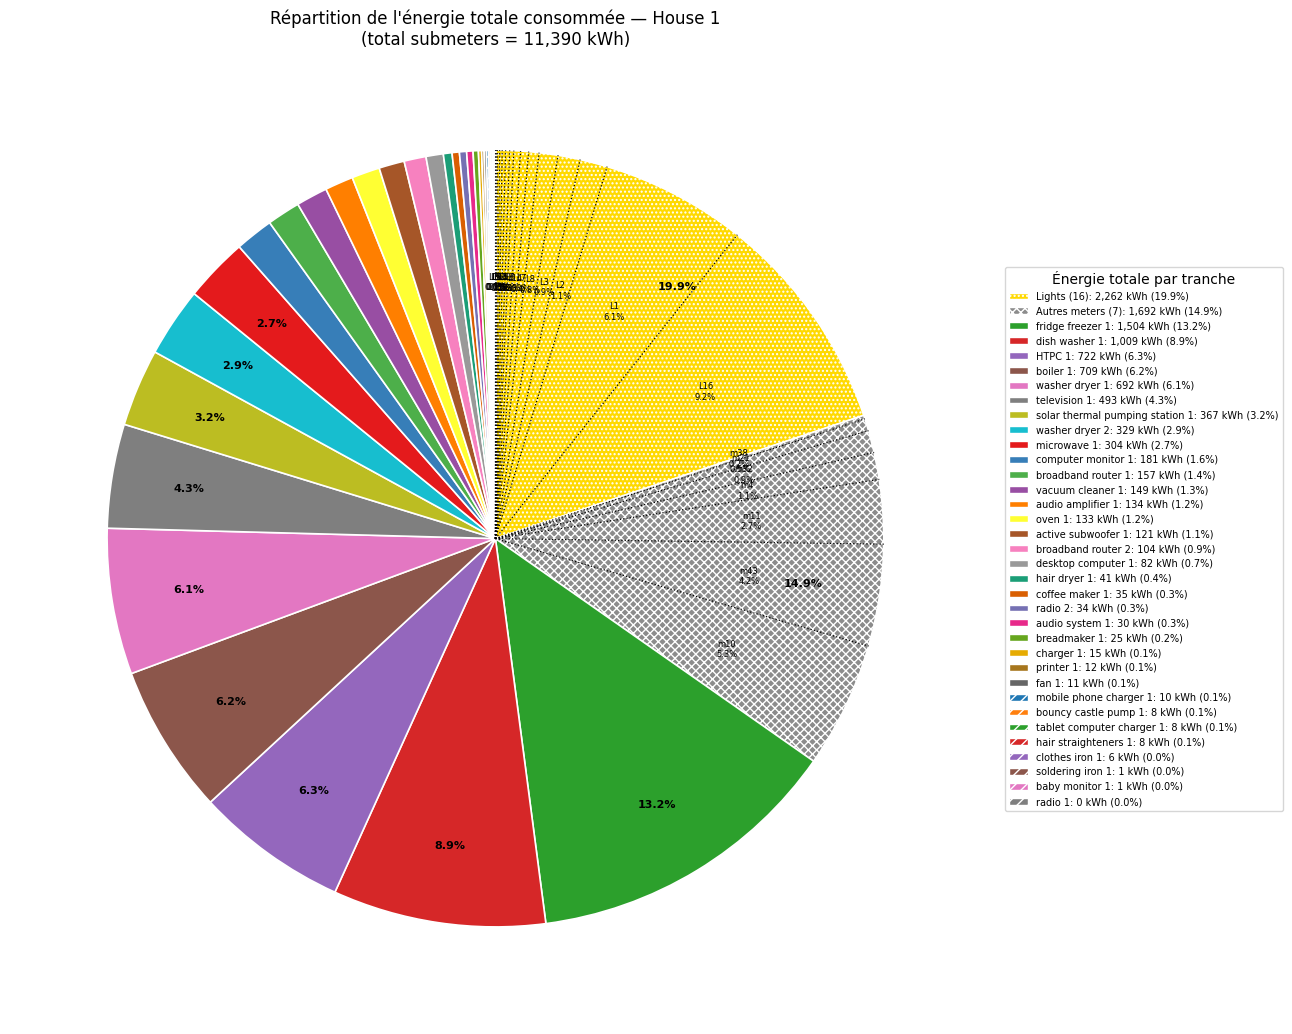

TOTAL submeters : 11,390.2 kWh

   19.9%      2,262.2 kWh   Lights (16)
   14.9%      1,692.1 kWh   Autres meters (7)
   13.2%      1,504.5 kWh   fridge freezer 1
    8.9%      1,008.7 kWh   dish washer 1
    6.3%        722.3 kWh   HTPC 1
    6.2%        709.3 kWh   boiler 1
    6.1%        692.0 kWh   washer dryer 1
    4.3%        492.9 kWh   television 1
    3.2%        367.3 kWh   solar thermal pumping station 1
    2.9%        328.8 kWh   washer dryer 2
    2.7%        303.8 kWh   microwave 1
    1.6%        181.3 kWh   computer monitor 1
    1.4%        157.3 kWh   broadband router 1
    1.3%        149.2 kWh   vacuum cleaner 1
    1.2%        134.1 kWh   audio amplifier 1
    1.2%        133.4 kWh   oven 1
    1.1%        120.6 kWh   active subwoofer 1
    0.9%        104.1 kWh   broadband router 2
    0.7%         82.0 kWh   desktop computer 1
    0.4%         40.9 kWh   hair dryer 1
    0.3%         34.6 kWh   coffee maker 1
    0.3%         33.9 kWh   radio 2
    0.3%       

In [29]:
# ===== CELLULE 11 : pie chart énergie totale — couleurs contrastées + hachures =====
import numpy as np
import matplotlib.pyplot as plt

def energie_kwh(s):
    s = s.dropna()
    return float(s.sum()) * SAMPLE_PERIOD / 3600 / 1000 if len(s) else 0.0

# 1) énergie + nature
energ, kind_of = {}, {}
for k, s in {**D_active, **D_apparent}.items():
    name = f"{k.type} {k.instance}"
    energ[name] = energie_kwh(s)
    kind_of[name] = 'lights' if k.type == 'light' else 'indiv'
for lbl, s in autres.items():
    energ[lbl] = energie_kwh(s)
    kind_of[lbl] = 'autres'

lights   = {n: e for n, e in energ.items() if kind_of[n] == 'lights'}
autres_e = {n: e for n, e in energ.items() if kind_of[n] == 'autres'}
indiv    = {n: e for n, e in energ.items() if kind_of[n] == 'indiv'}

# 2) tranches majeures triées décroissant
major = [(n, e, 'indiv') for n, e in indiv.items()]
if lights:
    major.append((f"Lights ({len(lights)})", sum(lights.values()), 'lights'))
if autres_e:
    major.append((f"Autres meters ({len(autres_e)})", sum(autres_e.values()), 'autres'))
major.sort(key=lambda t: t[1], reverse=True)

total  = sum(e for _, e, _ in major)
labels = [m[0] for m in major]
sizes  = [m[1] for m in major]

# 3) styles : couleurs contrastées (tab10+Set1+Dark2) x hachures -> chaque tranche unique
base_colors = (list(plt.cm.tab10.colors) + list(plt.cm.Set1.colors)
               + list(plt.cm.Dark2.colors))
hatches_cycle = ['', '///', '...', 'xxx', '\\\\\\', '+++', 'ooo', '**', '||', '--']

n = len(major)
colors  = [base_colors[i % len(base_colors)] for i in range(n)]
# change de hachure à chaque fois qu'on reboucle sur les couleurs
hatches = [hatches_cycle[(i // len(base_colors)) % len(hatches_cycle)] for i in range(n)]
# les deux agrégats reçoivent un style réservé bien identifiable
for i, (lab, e, knd) in enumerate(major):
    if knd == 'lights':
        colors[i] = (1.0, 0.85, 0.0); hatches[i] = '....'   # jaune pointillé
    elif knd == 'autres':
        colors[i] = (0.55, 0.55, 0.55); hatches[i] = 'xxxx' # gris croisé

def fmt(p):
    return f'{p:.1f}%' if p >= 2.0 else ''

fig, ax = plt.subplots(figsize=(13, 13))
wedges, _, autotexts = ax.pie(
    sizes, colors=colors, autopct=fmt, pctdistance=0.80,
    startangle=90, counterclock=False,
    wedgeprops=dict(edgecolor='white', linewidth=1.2),
    textprops=dict(fontsize=8, weight='bold'))
for w, h in zip(wedges, hatches):
    w.set_hatch(h)
for t in autotexts:
    t.set_color('black')
ax.set_aspect('equal')

# 4) subdivision interne des deux agrégats (rayons pointillés)
def subdivise(wedge, subitems, total_all):
    subitems = sorted(subitems.items(), key=lambda t: t[1], reverse=True)
    ssum = sum(e for _, e in subitems)
    if ssum <= 0:
        return
    t1, t2 = wedge.theta1, wedge.theta2
    cx, cy = wedge.center
    r = wedge.r
    cum = 0.0
    for j, (nm, e) in enumerate(subitems):
        frac = e / ssum
        mid = np.deg2rad(t1 + (cum + frac / 2) * (t2 - t1))
        rl = 0.66 * r
        short = nm.replace('autres_meter_', 'm').replace('light ', 'L')
        ax.text(cx + rl*np.cos(mid), cy + rl*np.sin(mid),
                f"{short}\n{100*e/total_all:.1f}%",
                ha='center', va='center', fontsize=6)
        cum += frac
        if j < len(subitems) - 1:
            b = np.deg2rad(t1 + cum * (t2 - t1))
            ax.plot([cx, cx + r*np.cos(b)], [cy, cy + r*np.sin(b)],
                    linestyle=':', color='black', linewidth=0.9)

for w, (lab, e, knd) in zip(wedges, major):
    if knd == 'lights':
        subdivise(w, lights, total)
    elif knd == 'autres':
        subdivise(w, autres_e, total)

# 5) légende avec patches assortis (couleur + hachure)
import matplotlib.patches as mpatches
handles = [mpatches.Patch(facecolor=colors[i], hatch=hatches[i],
                          edgecolor='white',
                          label=f"{labels[i]}: {sizes[i]:,.0f} kWh "
                                f"({100*sizes[i]/total:.1f}%)")
           for i in range(n)]
ax.legend(handles=handles, title="Énergie totale par tranche",
          loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=7)

ax.set_title(f"Répartition de l'énergie totale consommée — House 1\n"
             f"(total submeters = {total:,.0f} kWh)", fontsize=12)
plt.tight_layout(); plt.show()

# récap
print(f"TOTAL submeters : {total:,.1f} kWh\n")
for lab, e, _ in major:
    print(f"  {100*e/total:5.1f}%   {e:10,.1f} kWh   {lab}")
print("\nDétail Lights :")
for nm, e in sorted(lights.items(), key=lambda t: t[1], reverse=True):
    print(f"  {100*e/total:5.1f}%   {e:10,.1f} kWh   {nm}")
print("\nDétail Autres meters :")
for nm, e in sorted(autres_e.items(), key=lambda t: t[1], reverse=True):
    print(f"  {100*e/total:5.1f}%   {e:10,.1f} kWh   {nm}")